# Assignment M8: Ensemble Trees and KNN Models
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   KhramtchenkoGeorgeOPIM5604AssignmentM7.ipynb
*   OPIM 5604 Module 8 Ensemble Tree Models.ipynb
*   OPIM 5604 Module 8 KNN.ipynb
*   Google Gemini


# Environment Setup

In [145]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [146]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load the Data

**Prompt 1:** Read in the Spotify dataset and determine how many rows and columns it has.

In [147]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 8/Assignment 8/spotify-2023.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(953, 24)


**Answer:** This dataset has **953** rows and **24** columns.

Print the head elements of each column row for initial data visualization.

In [148]:
# Preview
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  ...  bpm key   mode  \
0                147  141381703               

List all columns with their corresponding data types.

In [149]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

**Prompt 2:** The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it. Hint: if needed, drop a row of problematic data to get it to convert properly.

In [150]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

Found problematic row(s) in 'streams' column:                               track_name     artist(s)_name  artist_count  \
574  Love Grows (Where 

**Prompt 3:** Partition the data into a 60/20/20 split.

In [151]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable
target = 'streams'
features = df.drop(target, axis=1)

# Identify and drop non-numeric columns that are not suitable for direct use in a regression tree
cols_to_drop = ['track_name', 'artist(s)_name']
features = features.drop(cols_to_drop, axis=1)

# Identify columns that might contain non-numeric values that should be numeric
potential_numeric_cols = ['in_deezer_playlists', 'in_shazam_charts']

for col in potential_numeric_cols:
    # Attempt to convert to numeric, coercing errors to NaN
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Drop rows with NaN values that resulted from the coercion
features.dropna(inplace=True)
target_variable = df.loc[features.index, target] # Align target variable with cleaned features

# Identify categorical columns to encode (excluding the target variable and columns already dropped)
categorical_cols_to_encode = features.select_dtypes(include='object').columns.tolist()

# Create dummy variables for the identified categorical columns
features_encoded = pd.get_dummies(features, columns=categorical_cols_to_encode, drop_first=True)


# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features_encoded, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features_encoded.head())

Training set shape: (448, 30) (448,)
Validation set shape: (150, 30) (150,)
Test set shape: (150, 30) (150,)

Encoded Features Head:
   artist_count  released_year  released_month  released_day  \
0             2           2023               7            14   
1             1           2023               3            23   
2             1           2023               6            30   
3             1           2019               8            23   
4             1           2023               5            18   

   in_spotify_playlists  in_spotify_charts  in_apple_playlists  \
0                   553                147                  43   
1                  1474                 48                  48   
2                  1397                113                  94   
3                  7858                100                 116   
4                  3133                 50                  84   

   in_apple_charts  in_deezer_playlists  in_deezer_charts  ...  key_B  key_C#  \
0   

#Random Forest

**Prompt 4:** Build a random forest model with hyperparameter tuning to predict streams using all predictors.

*Step 1:* Build a random forest regressor model.

In [152]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_rf = rf_model.predict(X_train)

# Make predictions on validation set
y_val_pred_rf = rf_model.predict(X_val)

# Make predictions on test set
y_test_pred_rf = rf_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print("Random Forest Performance on Training Set:")
print(f"  RMSE: {rmse_train_rf:.4f}")
print(f"  R-squared: {r2_train_rf:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_val_rf = r2_score(y_val, y_val_pred_rf)

print("\nRandom Forest Performance on Validation Set:")
print(f"  RMSE: {rmse_val_rf:.4f}")
print(f"  R-squared: {r2_val_rf:.4f}")


# Calculate and print metrics for Test Set
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Performance on Test Set:")
print(f"  RMSE: {rmse_test_rf:.4f}")
print(f"  R-squared: {r2_test_rf:.4f}")

Random Forest Performance on Training Set:
  RMSE: 82079477.5625
  R-squared: 0.9493

Random Forest Performance on Validation Set:
  RMSE: 184259846.1913
  R-squared: 0.7419

Random Forest Performance on Test Set:
  RMSE: 217879739.0535
  R-squared: 0.6381


**Notes:** Minor overfitting seems to be present in the training partition. Step 2 addresses this concern.

*Step 2:* Perform hyperparameter tuning calculation.

In [153]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define a parameter grid for the Random Forest Regressor
# We'll tune n_estimators, max_depth, and min_samples_split for now
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],       # Maximum depth of the trees
    'min_samples_split': [15, 20, 25]    # Minimum number of samples required to split an internal node
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV with the Random Forest Regressor and the parameter grid
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring=neg_mse_scorer, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found for Random Forest:", grid_search_rf.best_params_)

# Convert the best score back to positive MSE or RMSE for easier interpretation
best_mse_rf = -grid_search_rf.best_score_
best_rmse_rf = np.sqrt(best_mse_rf)
print(f"Best cross-validation RMSE for Random Forest: {best_rmse_rf:.4f}")

Best hyperparameters found for Random Forest: {'max_depth': None, 'min_samples_split': 15, 'n_estimators': 200}
Best cross-validation RMSE for Random Forest: 222737260.1490


*Step 3:* Rerun the model with the selected parameters.

In [154]:
# Retrieve the best hyperparameters for the Random Forest
best_params_rf = grid_search_rf.best_params_
print("Best hyperparameters for Random Forest:", best_params_rf)

# Instantiate a new Random Forest Regressor with the best hyperparameters
tuned_rf_model = RandomForestRegressor(**best_params_rf, random_state=42)

# Train the tuned model on the complete training dataset
tuned_rf_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned_rf = tuned_rf_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_rf = tuned_rf_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_rf = tuned_rf_model.predict(X_test)

Best hyperparameters for Random Forest: {'max_depth': None, 'min_samples_split': 15, 'n_estimators': 200}


**Note:** There was a solid improvement during this model run after hyperparameter tuning. Only slight overfitting exists now.

**Prompt 5:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

In [155]:
# Calculate and print metrics for Training Set
rmse_train_tuned_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_rf))
r2_train_tuned_rf = r2_score(y_train, y_train_pred_tuned_rf)

print("\nTuned Random Forest Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_rf:.4f}")
print(f"  R-squared: {r2_train_tuned_rf:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_rf))
r2_val_tuned_rf = r2_score(y_val, y_val_pred_tuned_rf)

print("\nTuned Random Forest Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_rf:.4f}")
print(f"  R-squared: {r2_val_tuned_rf:.4f}")

# Calculate and print metrics for Test Set
rmse_test_tuned_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_rf))
r2_test_tuned_rf = r2_score(y_test, y_test_pred_tuned_rf)

print("\nTuned Random Forest Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_rf:.4f}")
print(f"  R-squared: {r2_test_tuned_rf:.4f}")


Tuned Random Forest Performance on Training Set:
  RMSE: 128864250.9875
  R-squared: 0.8750

Tuned Random Forest Performance on Validation Set:
  RMSE: 189553309.5899
  R-squared: 0.7269

Tuned Random Forest Performance on Test Set:
  RMSE: 224463043.2691
  R-squared: 0.6159


View the performance visually by looking at the distribution of residuals and the actual by predicted plots, as well as the accompanying scatterplots.

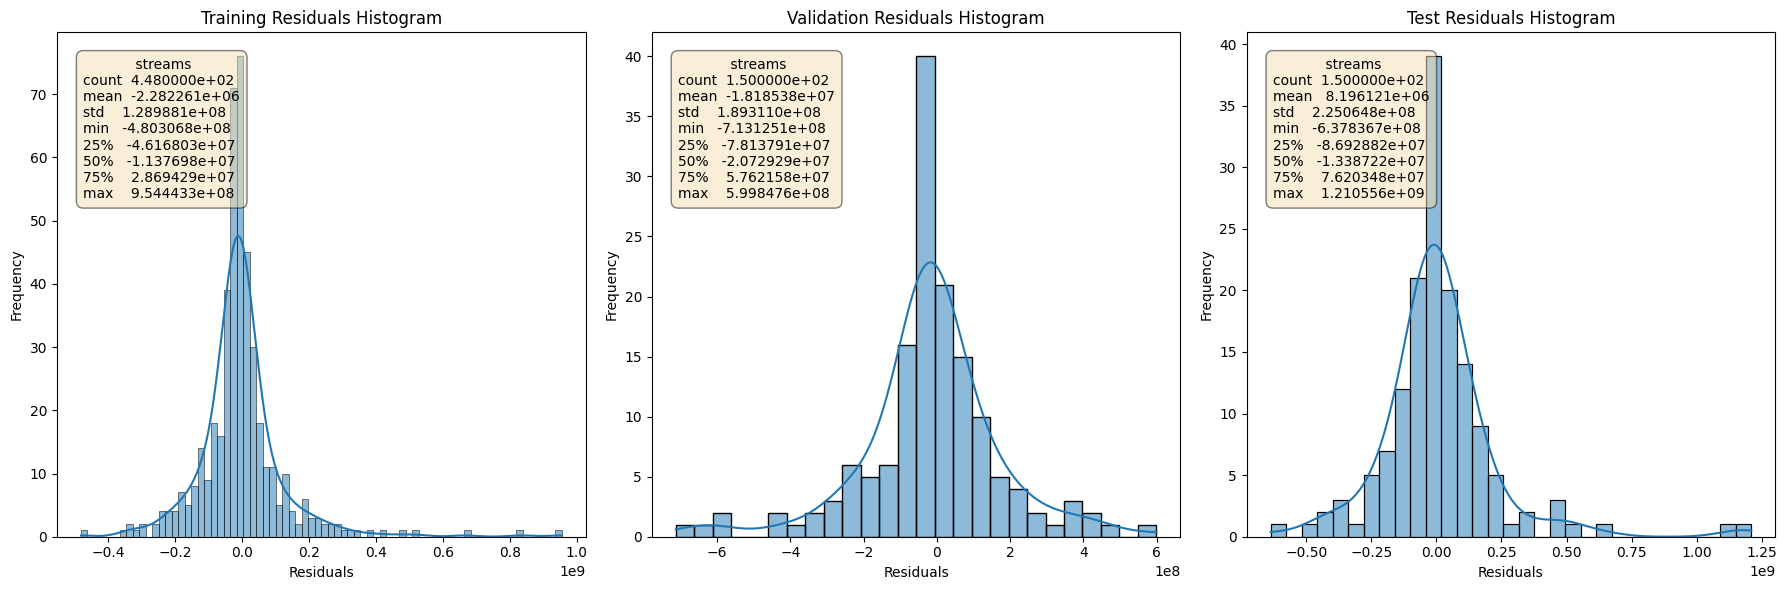

In [156]:
# Calculate residuals for each partition
train_residuals = y_train - y_train_pred_tuned_rf
val_residuals = y_val - y_val_pred_tuned_rf
test_residuals = y_test - y_test_pred_tuned_rf

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [157]:
# Remove the extreme negative value of min in the test residuals histogram
test_residuals = test_residuals[test_residuals > test_residuals.min()]

# Create dataframes with actual and predicted prices
# This is to ensure the plotting code has the necessary dataframes
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred_tuned_rf

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred_tuned_rf

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred_tuned_rf

Dataframes with actual and predicted streams created.


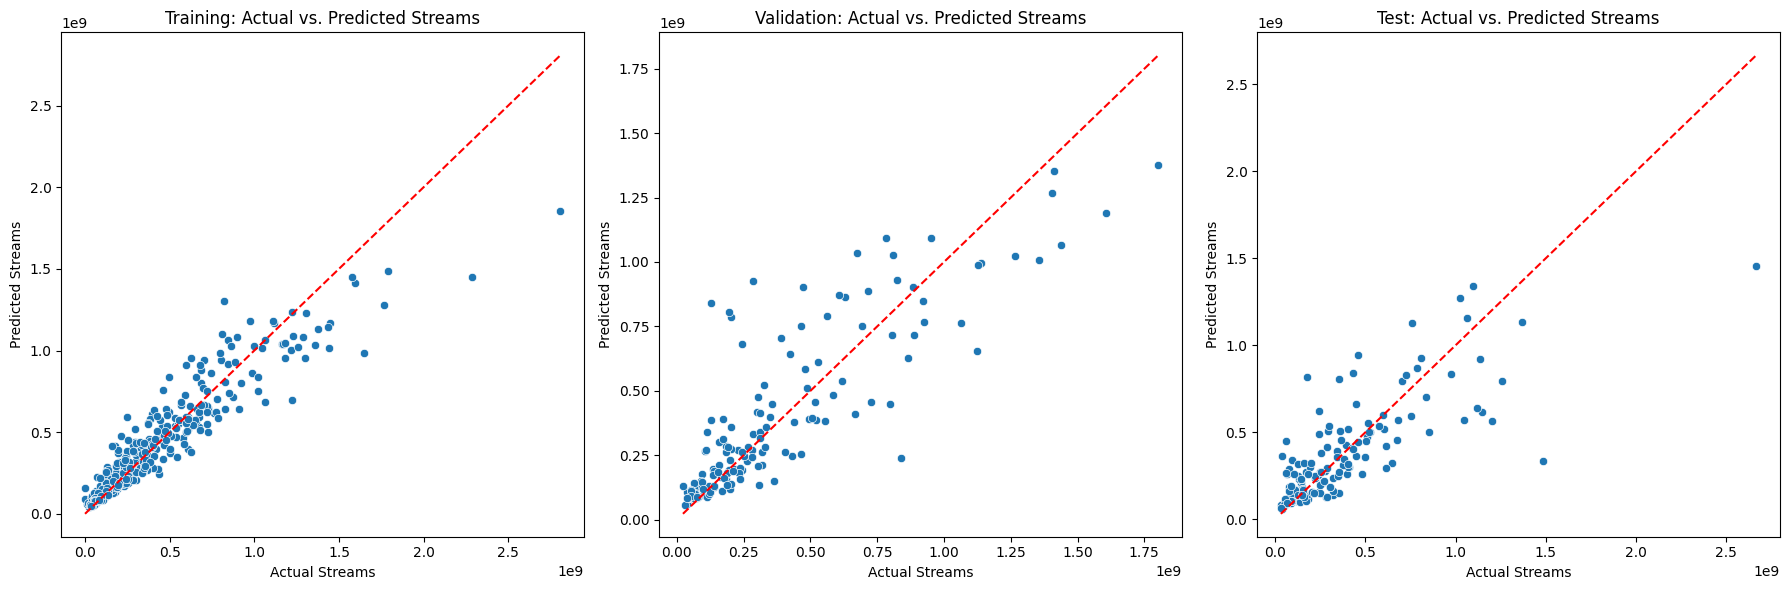

In [158]:
# Plot actual vs. predicted prices for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

print("Dataframes with actual and predicted streams created.")
plt.tight_layout()
plt.show()

**Prompt 6:** Comment on the model performance.  What did you observe in the results?

**Answer:** In the random forest regressor model, the RMSE was lowest in the training partition, followed by a decrease in the validation set before a slight increase in the test set. There was a noticeable drop in performance of the R-squared value between training and test partitions, with an approximately 30% reduction in R-squared value. Even when viewing the residuals histogram and the scatterplots, it is evident that model performance deteriorates rather sharply within the random forest regressor model between the training, validation, and testing partitions.

**Prompt 7:** Check for feature importance.  Which variables are the most important?  Did any predictors go unused?

In [159]:
import pandas as pd

# Get the feature importances from the tuned random forest model
feature_importances_rf = tuned_rf_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_rf = pd.Series(feature_importances_rf, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances_rf = feature_importance_series_rf.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Random Forest:")
print(sorted_feature_importances_rf)

Feature Importances for Tuned Random Forest:
in_spotify_playlists    0.693164
in_deezer_playlists     0.085735
in_spotify_charts       0.056744
released_year           0.031058
bpm                     0.023550
in_apple_playlists      0.020710
valence_%               0.013415
speechiness_%           0.010035
in_apple_charts         0.009681
acousticness_%          0.009427
in_shazam_charts        0.008971
liveness_%              0.006927
released_month          0.006300
energy_%                0.005575
in_deezer_charts        0.005368
released_day            0.004664
danceability_%          0.002913
key_B                   0.001647
key_C#                  0.001188
instrumentalness_%      0.000506
key_A#                  0.000504
artist_count            0.000462
key_F#                  0.000403
mode_Minor              0.000285
key_G                   0.000277
key_E                   0.000239
key_D#                  0.000096
key_G#                  0.000088
key_F                   0.00003

**Answer:** The **in_spotify_playlists** is overwhelmingly the most important variable, followed by **in_deezer_playlists** and **in_spotify_charts**. There were no unused predictors, but **key_D** was the least used variable.

#Boosted Tree

**Prompt 8:** Build a boosted tree model with hyperparameter tuning to predict streams using all predictors.

In [160]:
from sklearn.ensemble import GradientBoostingRegressor

# Instantiate a Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model on the training data
gbr_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_gbr = gbr_model.predict(X_train)

# Make predictions on validation set
y_val_pred_gbr = gbr_model.predict(X_val)

# Make predictions on test set
y_test_pred_gbr = gbr_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_gbr = np.sqrt(mean_squared_error(y_train, y_train_pred_gbr))
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)

print("Gradient Boosting Regressor Performance on Training Set:")
print(f"  RMSE: {rmse_train_gbr:.4f}")
print(f"  R-squared: {r2_train_gbr:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_gbr = np.sqrt(mean_squared_error(y_val, y_val_pred_gbr))
r2_val_gbr = r2_score(y_val, y_val_pred_gbr)

print("\nGradient Boosting Regressor Performance on Validation Set:")
print(f"  RMSE: {rmse_val_gbr:.4f}")
print(f"  R-squared: {r2_val_gbr:.4f}")


# Calculate and print metrics for Test Set
rmse_test_gbr = np.sqrt(mean_squared_error(y_test, y_test_pred_gbr))
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

print("\nGradient Boosting Regressor Performance on Test Set:")
print(f"  RMSE: {rmse_test_gbr:.4f}")
print(f"  R-squared: {r2_test_gbr:.4f}")

Gradient Boosting Regressor Performance on Training Set:
  RMSE: 67354098.9682
  R-squared: 0.9658

Gradient Boosting Regressor Performance on Validation Set:
  RMSE: 181730460.0166
  R-squared: 0.7490

Gradient Boosting Regressor Performance on Test Set:
  RMSE: 210577803.0285
  R-squared: 0.6619


*Step 2:* Perform hyperparameter tuning calculation.

In [161]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define a parameter grid for the Gradient Boosting Regressor
# Key parameters to tune include n_estimators, learning_rate, max_depth, and min_samples_split
param_grid_gbr = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2], # Shrinkage on the contributions of each tree
    'max_depth': [3, 4, 5],           # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5, 10]    # Minimum number of samples required to split an internal node
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV with the Gradient Boosting Regressor and the parameter grid
grid_search_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gbr, cv=5, scoring=neg_mse_scorer, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_gbr.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found for Gradient Boosting Regressor:", grid_search_gbr.best_params_)

# Convert the best score back to positive MSE or RMSE for easier interpretation
best_mse_gbr = -grid_search_gbr.best_score_
best_rmse_gbr = np.sqrt(best_mse_gbr)
print(f"Best cross-validation RMSE for Gradient Boosting Regressor: {best_rmse_gbr:.4f}")

Best hyperparameters found for Gradient Boosting Regressor: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation RMSE for Gradient Boosting Regressor: 215608904.2770


*Step 3:* Rerun the model with the selected parameters.

In [162]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Retrieve the best hyperparameters for the Gradient Boosting Regressor
best_params_gbr = grid_search_gbr.best_params_
print("Best hyperparameters for Gradient Boosting Regressor:", best_params_gbr)

# Instantiate a new Gradient Boosting Regressor with the best hyperparameters
tuned_gbr_model = GradientBoostingRegressor(**best_params_gbr, random_state=42)

# Train the tuned model on the complete training dataset
tuned_gbr_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned_gbr = tuned_gbr_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_gbr = tuned_gbr_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_gbr = tuned_gbr_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_tuned_gbr = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_gbr))
r2_train_tuned_gbr = r2_score(y_train, y_train_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_gbr:.4f}")
print(f"  R-squared: {r2_train_tuned_gbr:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_gbr = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_gbr))
r2_val_tuned_gbr = r2_score(y_val, y_val_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_gbr:.4f}")
print(f"  R-squared: {r2_val_tuned_gbr:.4f}")

# Calculate and print metrics for Test Set
rmse_test_tuned_gbr = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_gbr))
r2_test_tuned_gbr = r2_score(y_test, y_test_pred_tuned_gbr)

print("\nTuned Gradient Boosting Regressor Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_gbr:.4f}")
print(f"  R-squared: {r2_test_tuned_gbr:.4f}")

Best hyperparameters for Gradient Boosting Regressor: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Gradient Boosting Regressor Performance on Training Set:
  RMSE: 67354098.9682
  R-squared: 0.9658

Tuned Gradient Boosting Regressor Performance on Validation Set:
  RMSE: 181730460.0166
  R-squared: 0.7490

Tuned Gradient Boosting Regressor Performance on Test Set:
  RMSE: 210577803.0285
  R-squared: 0.6619


View the performance visually by looking at the distribution of residuals and the actual by predicted plots, as well as the accompanying scatterplots.

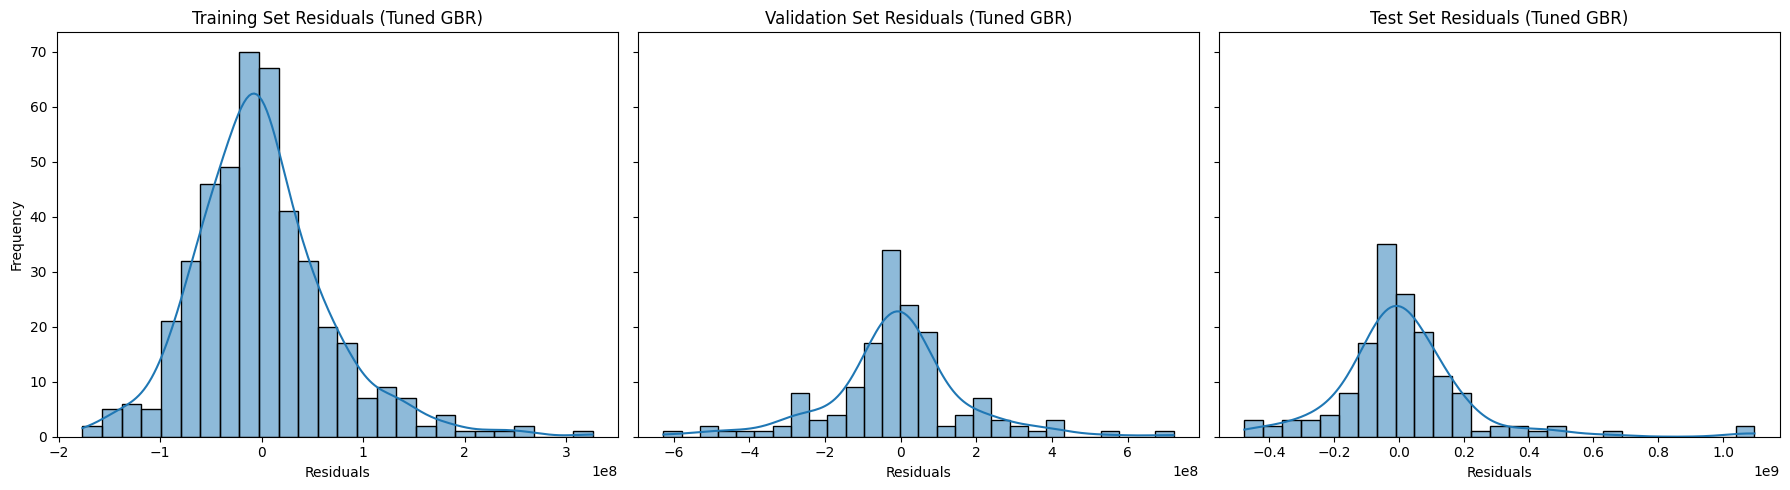

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for each set using the tuned Gradient Boosting Regressor model
residuals_train_gbr = y_train - y_train_pred_tuned_gbr
residuals_val_gbr = y_val - y_val_pred_tuned_gbr
residuals_test_gbr = y_test - y_test_pred_tuned_gbr

# Create a figure and axes for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot the distribution of residuals for the training set
sns.histplot(residuals_train_gbr, kde=True, ax=axes[0])
axes[0].set_title('Training Set Residuals (Tuned GBR)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Plot the distribution of residuals for the validation set
sns.histplot(residuals_val_gbr, kde=True, ax=axes[1])
axes[1].set_title('Validation Set Residuals (Tuned GBR)')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

# Plot the distribution of residuals for the test set
sns.histplot(residuals_test_gbr, kde=True, ax=axes[2])
axes[2].set_title('Test Set Residuals (Tuned GBR)')
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plots
plt.show()

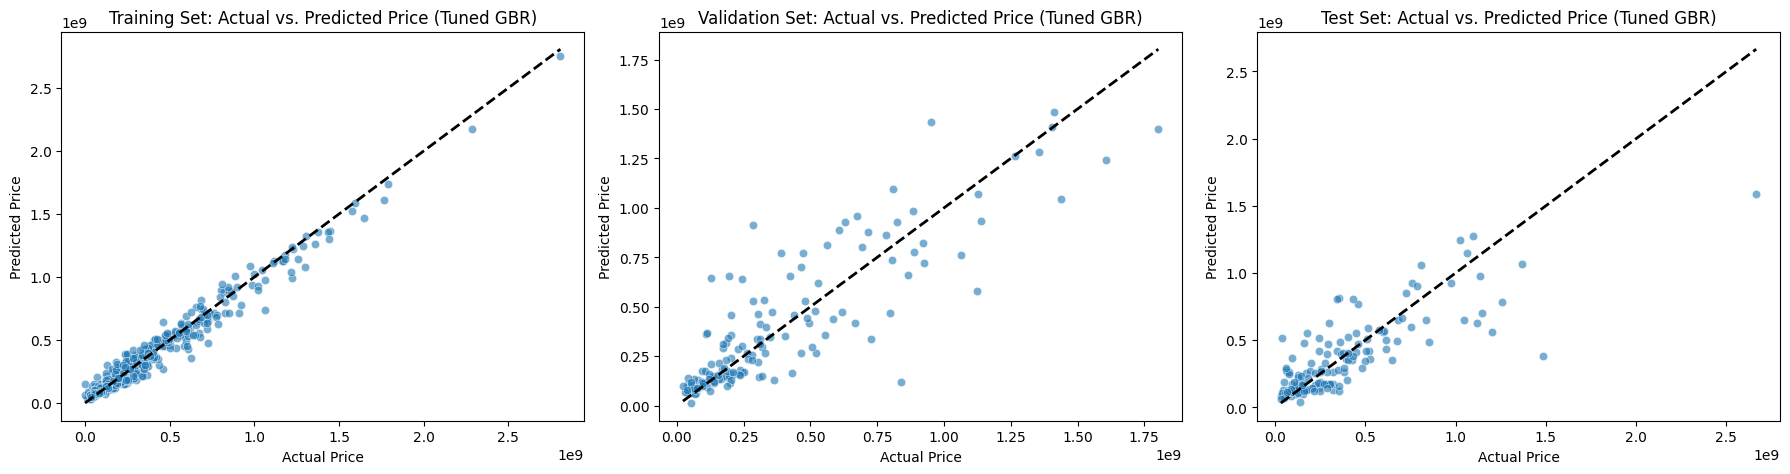

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axes for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot actual vs. predicted for the training set
sns.scatterplot(x=y_train, y=y_train_pred_tuned_gbr, ax=axes[0], alpha=0.6)
axes[0].set_title('Training Set: Actual vs. Predicted Price (Tuned GBR)')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2) # Add a diagonal line

# Plot actual vs. predicted for the validation set
sns.scatterplot(x=y_val, y=y_val_pred_tuned_gbr, ax=axes[1], alpha=0.6)
axes[1].set_title('Validation Set: Actual vs. Predicted Price (Tuned GBR)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2) # Add a diagonal line


# Plot actual vs. predicted for the test set
sns.scatterplot(x=y_test, y=y_test_pred_tuned_gbr, ax=axes[2], alpha=0.6)
axes[2].set_title('Test Set: Actual vs. Predicted Price (Tuned GBR)')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Add a diagonal line


# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

**Prompt 9:** Comment on the model performance.  What did you observe in the results?

**Answer:** The tuned gradient boosting regressor model's training partition seemed to be overfitted right at the start, with a very high R-squared value observed despite having the lowest RMSE value. The validation set saw a significant deterioration in both the RMSE and R-squared values, a trend that extended into the test set. R-squared fell by 30% between 0.96 and 0.66, and the residual distribution and the actual predicted scatterplots confirmed this trend.

**Prompt 10:** Check for feature importance. Which variables are the most important? Did any predictors go unused?

In [165]:
import pandas as pd

# Get the feature importances from the tuned gradient boosting regressor model
feature_importances_gbr = tuned_gbr_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_gbr = pd.Series(feature_importances_gbr, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances_gbr = feature_importance_series_gbr.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Gradient Boosting Regressor:")
print(sorted_feature_importances_gbr)

Feature Importances for Tuned Gradient Boosting Regressor:
in_spotify_playlists    0.628039
in_deezer_playlists     0.081675
in_spotify_charts       0.064691
released_year           0.061270
bpm                     0.034319
in_apple_playlists      0.027169
energy_%                0.015352
valence_%               0.012952
speechiness_%           0.012856
acousticness_%          0.011836
in_deezer_charts        0.008617
released_month          0.008301
in_apple_charts         0.007683
released_day            0.007100
in_shazam_charts        0.005729
danceability_%          0.003302
liveness_%              0.002965
key_B                   0.002895
instrumentalness_%      0.001495
artist_count            0.000934
key_F#                  0.000467
mode_Minor              0.000172
key_A#                  0.000116
key_D                   0.000067
key_C#                  0.000000
key_D#                  0.000000
key_F                   0.000000
key_E                   0.000000
key_G            

**Answer:** The **in_spotify_playlists** is once again overwhelmingly the most important variable, followed by **in_deezer_playlists** and **in_spotify_charts**, and **released_year**. There were a total of 6 unused predictors, which consisted of the **key_C#**, **key_D#**, **key_F**, **key_E**, **key_G**, and **key_G#** variables.

#Model Comparison

**Prompt 11:** Compare the results of the random forest to the boosted tree model.  Which one is better?  Justify your choice.

In [166]:
import pandas as pd

# Collect performance metrics for each tuned model
# Tuned Random Forest
metrics_rf = {
    'Model': 'Tuned Random Forest',
    'RMSE (Train)': rmse_train_tuned_rf,
    'R2 (Train)': r2_train_tuned_rf,
    'RMSE (Validation)': rmse_val_tuned_rf,
    'R2 (Validation)': r2_val_tuned_rf,
    'RMSE (Test)': rmse_test_tuned_rf,
    'R2 (Test)': r2_test_tuned_rf
}

# Tuned Gradient Boosting Regressor
metrics_gbr = {
    'Model': 'Tuned Gradient Boosting Regressor',
    'RMSE (Train)': rmse_train_tuned_gbr,
    'R2 (Train)': r2_train_tuned_gbr,
    'RMSE (Validation)': rmse_val_tuned_gbr,
    'R2 (Validation)': r2_val_tuned_gbr,
    'RMSE (Test)': rmse_test_tuned_gbr,
    'R2 (Test)': r2_test_tuned_gbr
}

# Create a list of metric dictionaries
all_metrics = [metrics_rf, metrics_gbr]

# Create a pandas DataFrame
metrics_df = pd.DataFrame(all_metrics)

# Set 'Model' as the index for better readability
metrics_df = metrics_df.set_index('Model')

# Round the numeric columns to 2 decimal places
metrics_df_rounded = metrics_df.round(2)


# Display the comparison table
print("Model Performance Comparison:")
display(metrics_df_rounded)

Model Performance Comparison:


,RMSE (Train),R2 (Train),RMSE (Validation),R2 (Validation),RMSE (Test),R2 (Test)
Model,,,,,,
Tuned Random Forest,1.288643e+08,0.87,1.895533e+08,0.73,2.244630e+08,0.62
Tuned Gradient Boosting Regressor,6.735410e+07,0.97,1.817305e+08,0.75,2.105778e+08,0.66


**Answer:** Upon comparing the results of the random forest and the boosted tree models, the boosted tree model is significantly better than the random forest model. The RMSE and R2 metrics, in addition to the previously provided residual histograms and scatterplots, showed an undeniable performance improvement in the boosted tree model across each individual partition, highlighting the effectiveness of this model over the tuned random forest model.

**Prompt 12:** Read in the Telco dataset and determine how many rows and columns it has.

In [167]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 8/Assignment 8/Telco_customer_churn.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(7043, 18)


**Answer:** This dataset has **7,043** rows and **18** columns.

**Prompt 13:** Partition the data into a 60/20/20 split.

We have a mix of categorical and continuous predictors. I'll change the target variable to 1s and 0s.

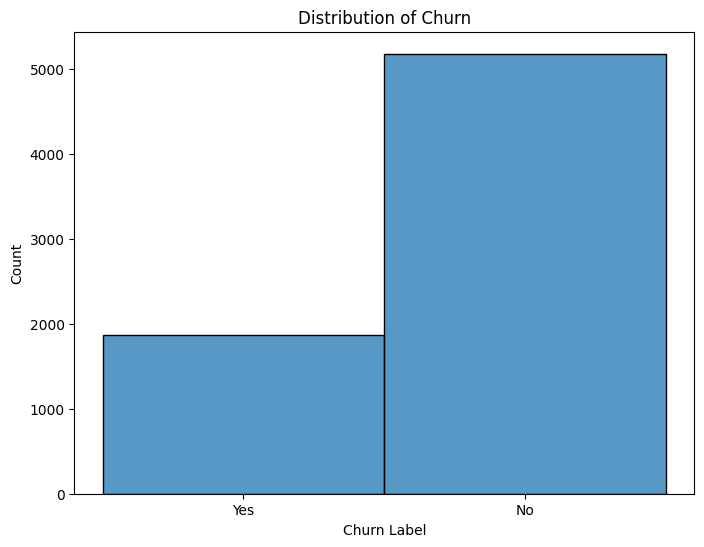


Counts of Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [168]:
# Show a histogram of 'Churn Label' counts
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Churn Label', bins=2) # bins=2 for two categories (0 and 1)
plt.title('Distribution of Churn')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.xticks([0, 1]) # Set x-axis ticks at 0 and 1
plt.show()

# Display counts
churn_counts = df['Churn Label'].value_counts()
print("\nCounts of Churn Label")
print(churn_counts)

In [169]:
# Convert 'Churn Label' to numerical (Yes=1, No=0) using map
df['Churn Value'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Drop CustomerID because it has too many categories and is irrelevant to this assignment.

In [170]:
# Drop the 'CustomerID' column
df = df.drop('CustomerID', axis=1)

Show a bar plot of the contract types to see if it can be used for dummy variables.

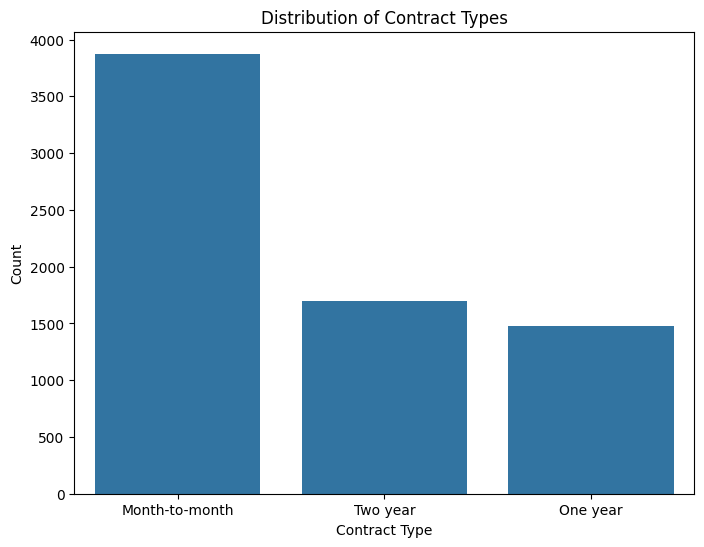


Counts of Contract Levels:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Percentages of Contract Levels:
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


In [171]:
# Show a histogram/bar plot of 'Contract' with counts
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Display counts and percentages
contract_counts = df['Contract'].value_counts()
contract_percentages = df['Contract'].value_counts(normalize=True) * 100

print("\nCounts of Contract Levels:")
print(contract_counts)

print("\nPercentages of Contract Levels:")
print(contract_percentages)

Create dummy variable(s) before building the KNN model.

In [172]:
# Create dummy variables for 'Contract'
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Multiple Lines  \
0    Male             No      No         No              2             No   
1  Female             No      No        Yes              2             No   
2  Female             No      No        Yes              8            Yes   
3  Female             No     Yes        Yes             28            Yes   
4    Male             No      No        Yes             49            Yes   

  Internet Service Online Security Online Backup Device Protection  \
0              DSL             Yes           Yes                No   
1      Fiber optic              No            No                No   
2      Fiber optic              No            No               Yes   
3      Fiber optic              No            No               Yes   
4      Fiber optic              No           Yes               Yes   

  Tech Support Paperless Billing Electronic Check  Monthly Charges  \
0           No               Yes              

Partition the data to prepare for modeling, utilizing Churn Label as the target variable with the rest of the columns being used as our initial predictor variables. A 60/20/20 split will be utilized.

In [173]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Identify categorical columns to encode (excluding 'CustomerID' and 'Churn Label' and 'Churn Value' which are handled)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn Label')

# Create dummy variables for all identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define the target variable
target = 'Churn Label'
# Define features by dropping the original target variable and 'Churn Value'
features = df_encoded.drop([target, 'Churn Value'], axis=1)
target_variable = df_encoded[target]

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features.head())

Training set shape: (4225, 18) (4225,)
Validation set shape: (1409, 18) (1409,)
Test set shape: (1409, 18) (1409,)

Encoded Features Head:
   Tenure Months  Monthly Charges  Contract_One year  Contract_Two year  \
0              2            53.85              False              False   
1              2            70.70              False              False   
2              8            99.65              False              False   
3             28           104.80              False              False   
4             49           103.70              False              False   

   Gender_Male  Senior Citizen_Yes  Partner_Yes  Dependents_Yes  \
0         True               False        False           False   
1        False               False        False            True   
2        False               False        False            True   
3        False               False         True            True   
4         True               False        False            True   

   Mult

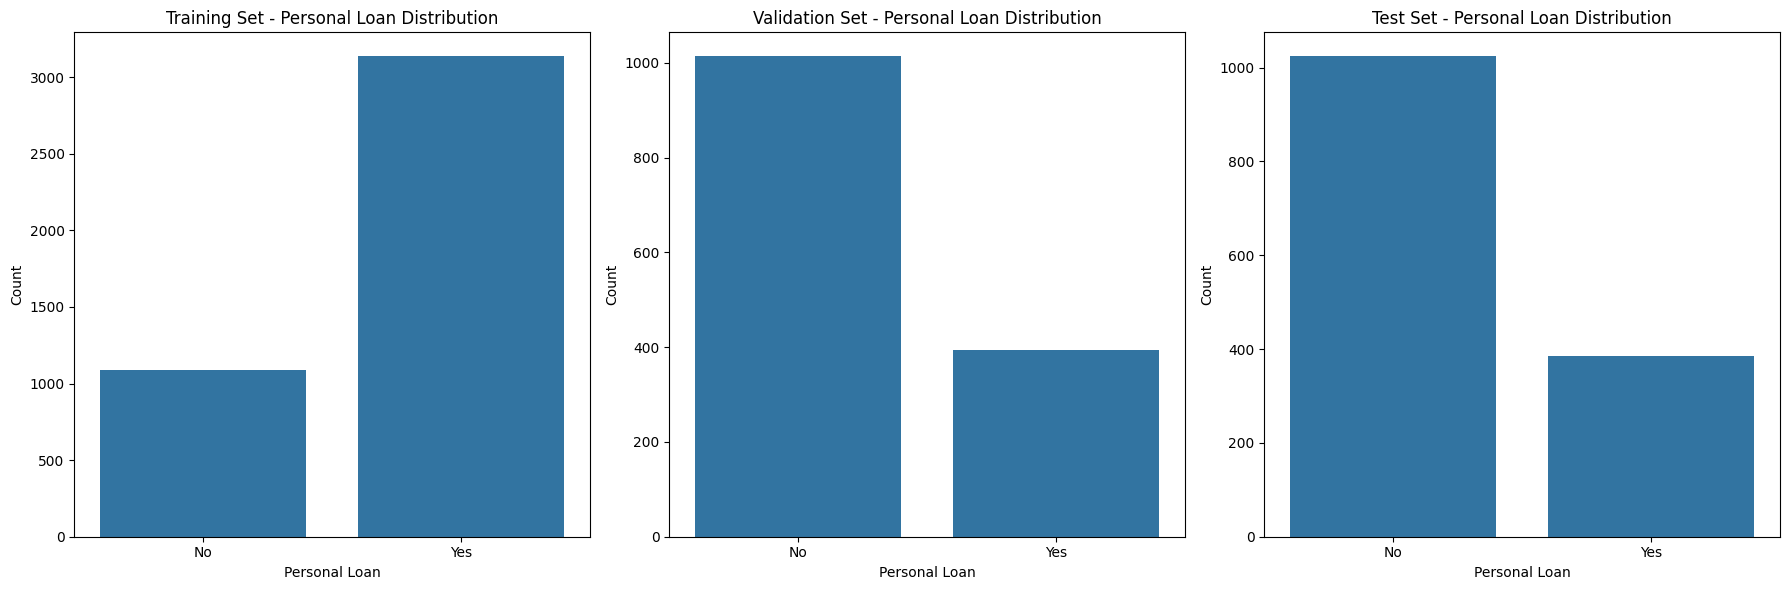

Training set Personal Loan counts and percentages:
Personal Loan
No     3136
Yes    1089
Name: count, dtype: int64
Personal Loan
No     74.22
Yes    25.78
Name: proportion, dtype: float64

Validation set Personal Loan counts and percentages:
Personal Loan
No     1014
Yes     395
Name: count, dtype: int64
Personal Loan
No     71.97
Yes    28.03
Name: proportion, dtype: float64

Test set Personal Loan counts and percentages:
Personal Loan
No     1024
Yes     385
Name: count, dtype: int64
Personal Loan
No     72.68
Yes    27.32
Name: proportion, dtype: float64


In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Personal Loan'] = y_train

val_data = X_val.copy()
val_data['Personal Loan'] = y_val

test_data = X_test.copy()
test_data['Personal Loan'] = y_test

# Plot the distribution of 'Personal Loan' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Personal Loan', ax=axs[0])
axs[0].set_title('Training Set - Personal Loan Distribution')
axs[0].set_xlabel('Personal Loan')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(data=val_data, x='Personal Loan', ax=axs[1])
axs[1].set_title('Validation Set - Personal Loan Distribution')
axs[1].set_xlabel('Personal Loan')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No', 'Yes'])


sns.countplot(data=test_data, x='Personal Loan', ax=axs[2])
axs[2].set_title('Test Set - Personal Loan Distribution')
axs[2].set_xlabel('Personal Loan')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Personal Loan counts and percentages:")
train_counts = train_data['Personal Loan'].value_counts()
train_percentages = train_data['Personal Loan'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places


print("\nValidation set Personal Loan counts and percentages:")
val_counts = val_data['Personal Loan'].value_counts()
val_percentages = val_data['Personal Loan'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places


print("\nTest set Personal Loan counts and percentages:")
test_counts = test_data['Personal Loan'].value_counts()
test_percentages = test_data['Personal Loan'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

#KNN for Classification

**Prompt 14:** Build a KNN model to predict churn using all predictors.

In [175]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a range of n_neighbors values to try
n_neighbors_range = range(1, 21) # Example range from 1 to 20

# Create lists to store results
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate through the range of n_neighbors values
for n in n_neighbors_range:
    # Initialize the KNN classifier with the current n_neighbors
    knn_classifier = KNeighborsClassifier(n_neighbors=n)

    # Train the model
    knn_classifier.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred_val = knn_classifier.predict(X_val)

    # Evaluate the model on the validation set
    accuracy = accuracy_score(y_val, y_pred_val)
    # Specify 'Yes' as the positive label for precision, recall, and f1_score
    precision = precision_score(y_val, y_pred_val, pos_label='Yes')
    recall = recall_score(y_val, y_pred_val, pos_label='Yes')
    f1 = f1_score(y_val, y_pred_val, pos_label='Yes')

    # Store the scores
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Now you have the performance metrics for each n_neighbors in the lists
# You can analyze these lists to find the best n_neighbors based on your preferred metric

**Prompt 15:** What is the best value for K?  How do you know?

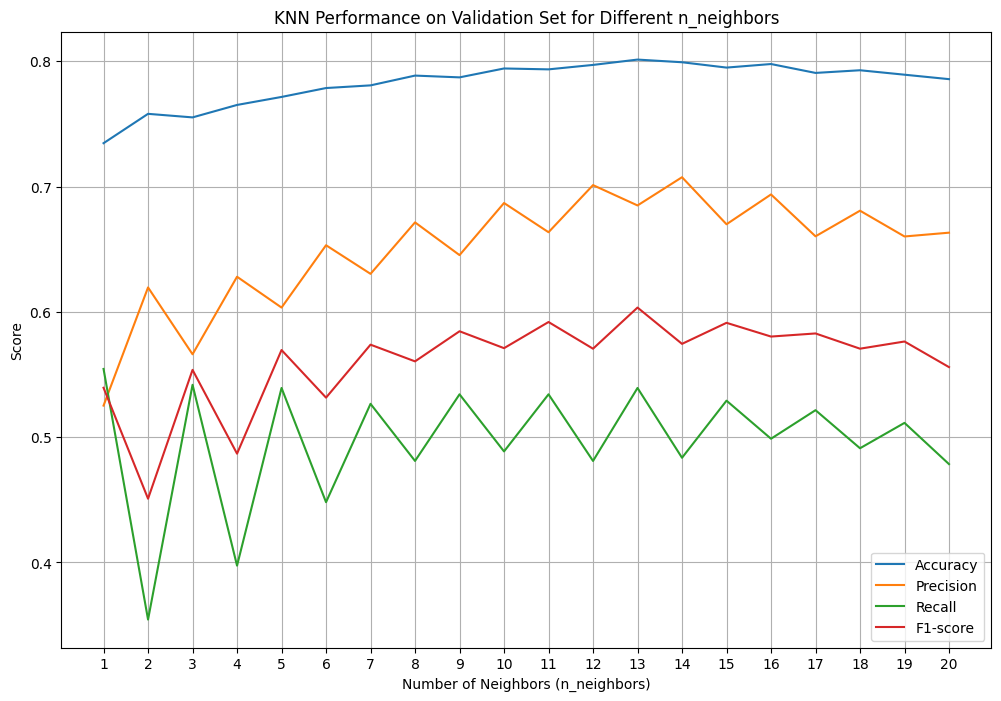

In [176]:
# Plot the performance metrics for each n_neighbors
plt.figure(figsize=(12, 8))

plt.plot(n_neighbors_range, accuracy_scores, label='Accuracy')
plt.plot(n_neighbors_range, precision_scores, label='Precision')
plt.plot(n_neighbors_range, recall_scores, label='Recall')
plt.plot(n_neighbors_range, f1_scores, label='F1-score')

plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance on Validation Set for Different n_neighbors')
plt.xticks(n_neighbors_range)
plt.legend()
plt.grid(True)
plt.show()

**Answer:** Based on this plot, K=13 appears to be the optimal value for K. It has the highest accuracy and F1 score and almost the highest precision and recall scores.

In [177]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier with n_neighbors=13
knn_classifier_13 = KNeighborsClassifier(n_neighbors=13)

# Train the model
knn_classifier_13.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_val_13 = knn_classifier_13.predict(X_val)

**Prompt 16:** Re-run the model with the optimal K.  Check model performance by partition with total accuracy, precision, recall, and F1 score.

In [178]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate on the training set
y_pred_train_13 = knn_classifier_13.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train_13)
precision_train = precision_score(y_train, y_pred_train_13, pos_label='Yes')
recall_train = recall_score(y_train, y_pred_train_13, pos_label='Yes')
f1_train = f1_score(y_train, y_pred_train_13, pos_label='Yes')

print("Performance metrics for Training Set (n_neighbors=13):")
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall: {recall_train:.4f}")
print(f"F1-score: {f1_train:.4f}")

# Evaluate on the validation set (predictions already made)
accuracy_val = accuracy_score(y_val, y_pred_val_13)
precision_val = precision_score(y_val, y_pred_val_13, pos_label='Yes')
recall_val = recall_score(y_val, y_pred_val_13, pos_label='Yes')
f1_val = f1_score(y_val, y_pred_val_13, pos_label='Yes')

print("\nPerformance metrics for Validation Set (n_neighbors=13):")
print(f"Accuracy: {accuracy_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1-score: {f1_val:.4f}")

# Evaluate on the test set
y_pred_test_13 = knn_classifier_13.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test_13)
precision_test = precision_score(y_test, y_pred_test_13, pos_label='Yes')
recall_test = recall_score(y_test, y_pred_test_13, pos_label='Yes')
f1_test = f1_score(y_test, y_pred_test_13, pos_label='Yes')

print("\nPerformance metrics for Test Set (n_neighbors=13):")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-score: {f1_test:.4f}")

Performance metrics for Training Set (n_neighbors=13):
Accuracy: 0.8097
Precision: 0.6694
Recall: 0.5170
F1-score: 0.5834

Performance metrics for Validation Set (n_neighbors=13):
Accuracy: 0.8013
Precision: 0.6849
Recall: 0.5392
F1-score: 0.6034

Performance metrics for Test Set (n_neighbors=13):
Accuracy: 0.7857
Precision: 0.6466
Recall: 0.4753
F1-score: 0.5479


**Prompt 17:** Comment on the model performance. What did you observe in the results?

**Answer:** Utilizing the KNN model, we see mixed results, but there is a negative trend in model performance across the three partitions. Between the training and validation sets, accuracy decreases slightly while precision, recall, and F1-score values increase minimally. However, between the validation and test partitions, all of the four metrics observe performance reductions.